## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import BiologicLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, fit_DRT_peaks, find_DRT_peaks, Z_from_DRT, extend_logspace_f
from redoxed.impedance.drt_solver import DRT_rr_solver

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline
# %matplotlib qt

# if think is slowing down, disable autoreload by restarting kernel without it.
# %load_ext autoreload
# %autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

## Load Data

In [ ]:
# initialise plot dictionaries

eis_plot_dict = {}
residuals_plot_dict = {}
drt_plot_dict = {}

#########################
##### Data loading ######
#########################

fpath = r"../data/cell_EIS_2.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 3) # only select 3rd cycle
EISData_object = ECData_object.to_EISData()
# EISData_object.crop_frequency(0.01, 2e5)
#EISData_object.crop_frequency(1e5, 2e5)

# load data to plot dictionary
EISData_object.label = "Cell"
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }


## DRT

DRT fitting requires many choices. Most of these have default values in redoxED, but can be changed, as shown below.

lambda: 5.420965888625909e-05
R0: 0.13535674806924694
L0: 3.268568537605068e-08
C0: nan
pseudo-chi-squared: 0.001206278417128726
pseudo-chi-squared (average): 8.205975626726028e-06


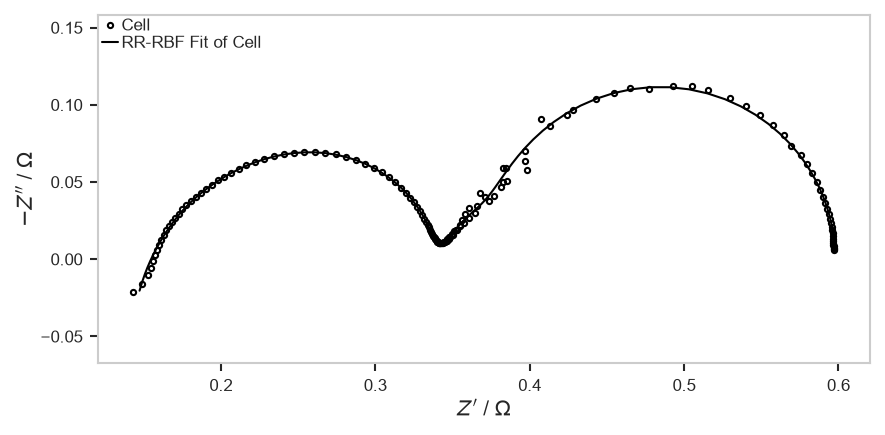

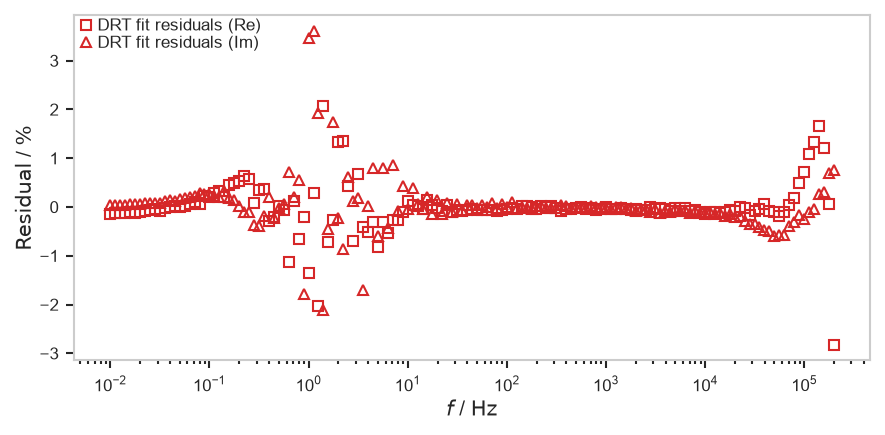

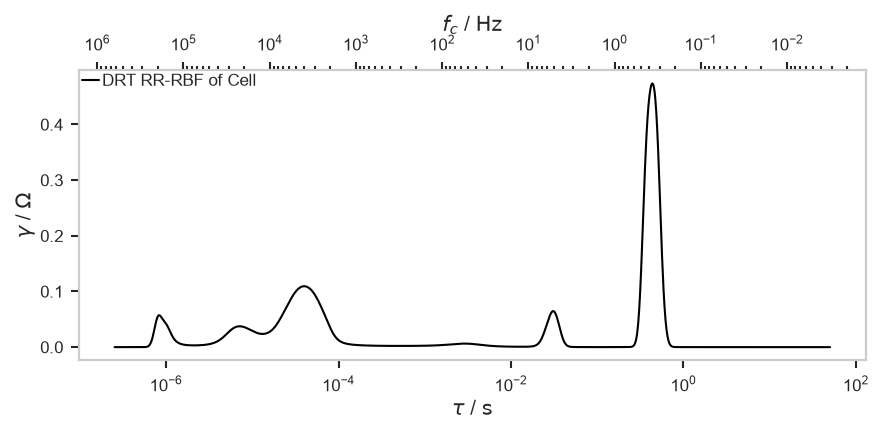

In [ ]:
#########################
###### DRT fitting ######
#########################

# crop frequency on basis of EIS validation
EISData_object.crop_frequency(0.01, 2e5)

### Choose appropriate tau_l_vec for DRT fitting. If None, will use default tau_l_vec based on EISData_object.f
# f_expanded = extend_logspace_f(EISData_object.f, 0.01, 2e6)
# tau_l_vec = 1 / (2 * np.pi * f_expanded)
tau_l_vec = None # use default if None

### Set initial lambda value and selection method.
lambda_value = 1e-9
lambda_selection = 'rgcv' # 'rgcv' or 'fixed' recommended
lambda_optimization = {
        "method": "differential_evolution", # "L-BFGS-B" etc are alternatives, but differential_evolution helps achieve a global optimum
        "bounds": [(np.log(1e-10), np.log(1e0))],
        "options": {"disp": False, "maxiter": 2000, "tol": 0.01, "atol": 0},
}

### Set quadrature options for DRT fitting. These are passed to scipy.integrate.quad, which is used to compute the integral in the DRT model. The default values are usually sufficient, but can be adjusted if needed.
quad_opts = {"a": -30, "b": 30, "epsabs": 1e-9, "epsrel": 1e-9}

### Create DRT solver object and calculate DRT
# For other DRT settings like weighting, RBF choices, and lumped element choices, consult the documentation of DRT_rr_solver
DRT_solver_object = DRT_rr_solver(EISData_object=EISData_object, tau_l_vec = tau_l_vec, lambda_value = lambda_value, lambda_selection = lambda_selection, lambda_optimization = lambda_optimization, quad_opts = quad_opts)
DRT_solver_object.calculate_drt()
EISData_fit = DRT_solver_object.EISData_fit
DRTData_fit = DRT_solver_object.DRTData_fit

# print lumped elements and lambda used nicely formatted
print(f'lambda: {DRT_solver_object.lambda_value}')
print(f'R0: {DRTData_fit.R0}')
print(f'L0: {DRTData_fit.L0}')
print(f'C0: {DRTData_fit.C0}')
print(f'pseudo-chi-squared: {DRT_solver_object.pseudo_chisqr}')
print(f'pseudo-chi-squared (average): {DRT_solver_object.pseudo_chisqr_avg}')


drt_plot_dict[DRTData_fit.label] = {
        "data": DRTData_fit,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_fit.label},
        "plot": True
    }
eis_plot_dict[EISData_fit.label] = {
        "data": EISData_fit,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": EISData_fit.label},
        "plot": True
    }

#########################
#### Fitted Residuals ###
#########################

observed = EISData_object
predicted = EISData_fit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": "DRT fit residuals"},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian') # gets a bit misleading for small Z
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        # if ResidualsPlot_object.Z_rep == 'polar':
        #     # disable phase plotting
        #     entry["data"].residuals_phase = None
        #     entry["data"].residuals_phase_rel = None
        #     ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(6, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# DRTPlot_object.add_minor_ticks(number_x = 9)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.ax.legend()
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

eis_plot_dict_store = eis_plot_dict.copy()
drt_plot_dict_store = drt_plot_dict.copy()
NyquistPlot_object_store = NyquistPlot_object.copy()
DRTPlot_object_store = DRTPlot_object.copy()

## Peak Fitting
Peak fitting requires choosing peak positions, a minimiser, peak shape, and bounds. Peak fitting should be sufficient so that the sum of $R_0$ and peaks captures the overall impedance.

Note that the fitted components are plotted without timescale overlap for ease of visualisation. 

Looking for up to  None  peaks
Peak positions (tau, gamma):


[(np.float64(8.365982090637695e-07), np.float64(0.05730984435891086)),
 (np.float64(7.155331327060812e-06), np.float64(0.03745361596219146)),
 (np.float64(3.9840061754243454e-05), np.float64(0.10946755069828645)),
 (np.float64(0.002914376383252315), np.float64(0.006362782849341917)),
 (np.float64(0.0306934109707324), np.float64(0.06464345203766174)),
 (np.float64(0.4359890154908464), np.float64(0.47367567161935226))]

,label,peak_type,peak_number,log_tau0,height,upsilon,sigma,tau0,Z
0,peak_0,SG,0,-13.996893,0.056882,-0.021809,0.173299,8.341166e-07,0.024721
1,peak_1,SG,1,-11.848370,0.034752,0.014112,0.468991,7.150199e-06,0.040862
2,peak_2,SG,2,-10.122007,0.115262,0.002845,0.468948,4.018537e-05,0.135489
3,peak_3,SG,3,-5.833784,0.006349,0.004693,0.692638,2.926980e-03,0.011023
4,peak_4,SG,4,-3.487116,0.061949,0.001917,0.172315,3.058896e-02,0.026758
5,peak_5,SG,5,-0.833759,0.495952,0.026170,0.182143,4.344132e-01,0.226590


{'success': True,
 'message': 'Optimization terminated successfully.',
 'chisqr': np.float64(0.033524459405901444),
 'redchi': np.float64(2.3184273448064624e-05),
 'nfev': 3081,
 'method': 'Nelder-Mead',
 'kws sent': {'method': 'Nelder-Mead', 'options': {'maxiter': 100000}}}

Max data Re:  0.5968751907348633
DRT Rp: 0.4625139765118721
DRT R0: 0.13535674806924694
DRT Rp + R0: 0.597870724581119
Peak sum Z0: 0.4654437760009035
Peak sum Z0 + R0: 0.6008005240701504
Inductance L: 3.268568537605068e-08


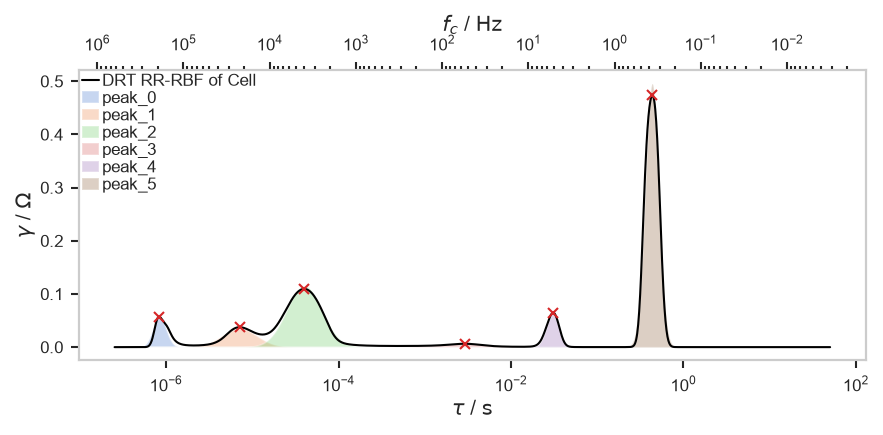

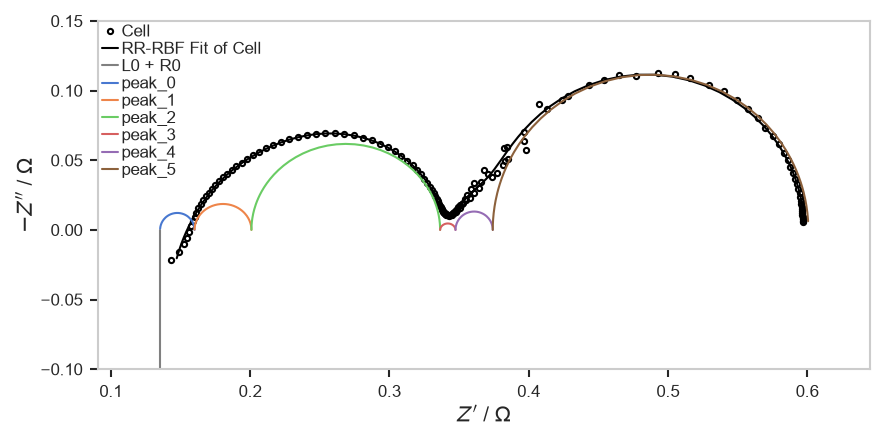

In [ ]:
eis_plot_dict = eis_plot_dict_store.copy()
drt_plot_dict = drt_plot_dict_store.copy()
NyquistPlot_object = NyquistPlot_object_store.copy()
DRTPlot_object = DRTPlot_object_store.copy()

##################
## Peak fitting ##
##################
peaks_to_fit = None # auto
#peaks_to_fit = 6
print("Looking for up to ", peaks_to_fit, " peaks")
peak_positions = find_DRT_peaks(DRTData_object = DRTData_fit, num_peaks = peaks_to_fit, find_peaks_settings = dict(height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None))

# # insert peak position if desired
# peak_positions.insert(2, (2e-4, 0.03))

# 6th peak nothing so delete
del peak_positions[6]  # remove 6th peak

print("Peak positions (tau, gamma):")
display(peak_positions)

for peak_pos in peak_positions:
    DRTPlot_object.add_plot(DRTData(tau = np.array([peak_pos[0]]), gamma = np.array([peak_pos[1]])), color = colour_dict["red"], marker = "x", linestyle = "")

### choose optimisation algorithm for peak fitting
# minimizer_settings = {"method": "leastsq", "fit_kws": {}} # L2 norm better for height
# minimizer_settings = {"method": "powell", "fit_kws": {}} # L1 so better for area
minimizer_settings = {"method": "nelder", "fit_kws": {}} # L1 + initial condtions: best so far

### Choose peak fit constraints and find
peak_fit = fit_DRT_peaks(
    DRTData_object = DRTData_fit,
    peak_positions = peak_positions, # if make none, uses num_peaks to find
    num_peaks =  None, # None if using peak positions instead
    peak_type = 'SG', # select HN or SG
    skew = True,
    log_tau0_bound = 0.2, # base e not 10 # about ± 10%, made fit much better due to easing contraint on tau0
    assym_bound = 1, # 1 is allow full assymetry, 0 is no skew
    minimizer_settings = minimizer_settings
    )

df = peak_fit.to_peaks_df(quad_opts=quad_opts)
display(df)
display(peak_fit.fit_summary)

print("Max data Re: ", np.max(EISData_object.Z_re))
print("DRT Rp:", DRTData_fit.get_pol_resistance())
print("DRT R0:", DRTData_fit.R0)
print("DRT Rp + R0:", DRTData_fit.get_pol_resistance() + DRTData_fit.R0)
print("Peak sum Z0:", df['Z'].sum())
print("Peak sum Z0 + R0:", df['Z'].sum() + DRTData_fit.R0)
print("Inductance L:", DRTData_fit.L0)

##################
## Create plots ##
##################

# quadrature options for numerical integration of Z_from_DRT, if using SG peaks. If using HN peaks, not needed as Z is calculated analytically.
quad_opts = {'epsabs': 1e-8, 'epsrel': 1e-8, 'limit': 200, 'a': -20, 'b': 5}


f_expanded = extend_logspace_f(EISData_object.f, 0.01, 5e6)

# plot series components
Z_tot = DRTData_fit.R0 + 1j * 2 * np.pi * f_expanded * DRTData_fit.L0
Z_peak_re = np.real(Z_tot)
Z_peak_im = np.imag(Z_tot)
NyquistPlot_object.ax.plot(Z_peak_re, -Z_peak_im, color = "grey", label = "L0 + R0")

# x_max = Z_tot.real[-1]
# NyquistPlot_object.ax.fill_between([0., x_max], [0, 0], [-0.1, -0.1], 
#                                     alpha=0.3, 
#                                     color=colour_dict["cyan"])

Z_tot = Z_peak_re[-1] # update total

for i, peak in enumerate(peak_fit):
    # DRTPlot_object.add_plot(DRTData(tau = DRTData_object.tau, gamma = peak.get_gamma(tau=DRTData_object.tau), label = peak.label))
    DRTPlot_object.ax.fill_between(DRTData_fit.tau, peak_fit.get_gamma(tau=DRTData_fit.tau, peak_indices = [i]), 0, where=(peak_fit.get_gamma(tau=DRTData_fit.tau) >= 0), alpha=0.3, label = df[df['peak_number']==i]['label'].values[0])
    peak_type = peak.peak_params['peak_type']
    if peak_type == "HN":
        peak_row = df[df['peak_number']==i]
        alpha = peak_row['alpha'].values[0]
        beta = peak_row['beta'].values[0]
        tau0 = peak_row['tau0'].values[0]
        Z0 = peak_row['Z0'].values[0]
        Z_peak = Z_tot + HN_Z(2*np.pi*f_expanded, Z0, tau0, alpha, beta)
    elif peak_type == "SG":
        # def gamma_func(tau):
        #     return peak.get_gamma(tau)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = gamma_func)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma)
        Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma, quad_opts=quad_opts)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma(tau = DRTData_fit.tau), tau = DRTData_fit.tau)
    Z_peak_re = np.real(Z_peak)
    Z_peak_im = np.imag(Z_peak)
    Z_tot = Z_peak_re[-1] # update total
    # not using EISData objects as frequency loses meaning
    NyquistPlot_object.ax.plot(Z_peak_re, -Z_peak_im, label = df[df['peak_number']==i]['label'].values[0])
    #NyquistPlot_object.ax.fill_between(Z_peak_re, -Z_peak_im, 0, alpha=0.3, label = df[df['peak_number']==i]['label'].values[0])

DRTPlot_object.ax.legend()
#DRTPlot_object.ax.set_ylim(-0.1, 0.5)
display(DRTPlot_object.fig)
# DRTPlot_object.ax.set_ylim(-0.1, 0.25)
# display(DRTPlot_object.fig)
NyquistPlot_object.ax.set_ylim(-0.1, 0.15)
NyquistPlot_object.ax.legend()
display(NyquistPlot_object.fig)

